In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df_hist = pd.read_csv('../../raw/olympics_historico.csv')
df_paris = pd.read_csv('../../raw/olympics_paris2024.csv')

df_hist.to_parquet('../../bronze/olympics_historico.parquet', index=False)
df_paris.to_parquet('../../bronze/olympics_paris2024.parquet', index=False)

print("Ficheiros convertidos para Parquet com sucesso!")

Ficheiros convertidos para Parquet com sucesso!


# Padronizando as bases de dados

In [3]:
df_paris_clean = pd.DataFrame({
    'year': 2024,
    'edition': '2024 Summer Olympics',
    'edition_id': 64, # Apenas um ID de continuidade
    'country': df_paris['country'],
    'country_noc': df_paris['country_code'],
    'gold': df_paris['Gold Medal'],
    'silver': df_paris['Silver Medal'],
    'bronze': df_paris['Bronze Medal'],
    'total': df_paris['Total']
})

df_consolidado = pd.concat([df_hist, df_paris_clean], ignore_index=True)

df_consolidado.to_parquet('../../bronze/medalhas_1986_2024.parquet', index=False)

print("Dados integrados e guardados na camada Bronze!")

Dados integrados e guardados na camada Bronze!


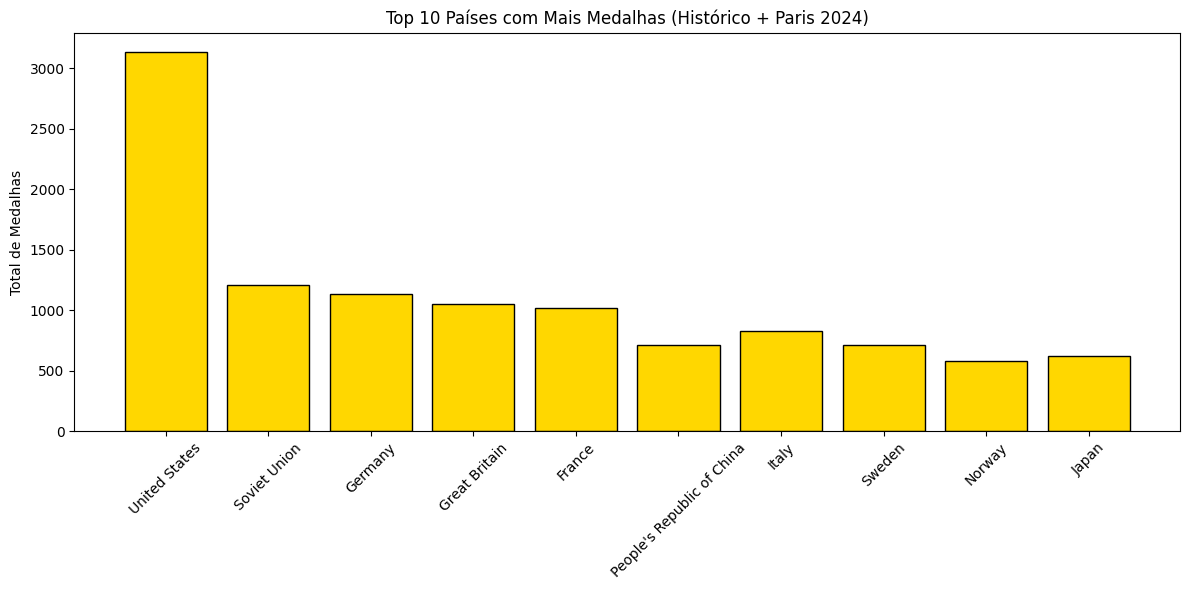

Relatórios e visualizações da camada Gold gerados com sucesso!


In [4]:
df_gold = df_consolidado.groupby('country')[['gold', 'silver', 'bronze', 'total']].sum().reset_index()

df_gold = df_gold.sort_values(by=['gold', 'silver', 'bronze'], ascending=False).head(50)

df_gold.to_csv('medalhas_summary.csv', index=False)

plt.figure(figsize=(12, 6))
plt.bar(df_gold['country'][:10], df_gold['total'][:10], color='gold', edgecolor='black')
plt.title('Top 10 Países com Mais Medalhas (Histórico + Paris 2024)')
plt.ylabel('Total de Medalhas')
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('medalhas_plot.png')
plt.show()

print("Relatórios e visualizações da camada Gold gerados com sucesso!")